<a href="https://colab.research.google.com/github/natsakh/ElectromagneticNets/blob/main/TimeVaryingMedia/PINNs/InitialValueProblems/Dielectric_temporal_slab_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

## Physical parameters

In [ ]:
n1 = 1.0  # dielectric permittivity before the temporal slab
n2 = 1.5  # dielectric permittivity inside the temporal slab
n3 = 1.0  # dielectric permittivity after the temporal slab

# Normalized angular frequencies with respect to tau = t / T_ref.
# The reference period is defined by the incident wave.
omega1 = 2.0 * np.pi
omega2 = (n1 / n2) * omega1
omega3 = (n1 / n3) * omega1

T_ref = 2.0 * np.pi / omega1  # equals 1.0 in the normalized variables

field_jump_scale_12 = (n1 / n2) ** 2
field_jump_scale_23 = (n2 / n3) ** 2


## Hyperparameters

In [ ]:
# Temporal slab position and total observation window in normalized time tau = t / T_ref
TAU1_LIST = [0.4, 1.2]
TAU_MAX = 3.0

# PINN collocation points
N_COLLOCATION_PER_PERIOD = 1000
N_MIN_COLLOCATION = 200

EPOCHS_MODEL1 = 8000
EPOCHS_MODEL2 = 8000

LEARNING_RATE = 1e-3
IC_WEIGHT = 20.0
GRAD_CLIP = 1.0

N_EVAL = 1500
SEED = 42

HIDDEN_DIM = 64
HIDDEN_LAYERS = 4

torch.manual_seed(SEED)
np.random.seed(SEED)


## Analytical solution

In [ ]:
def u_stage1_analytic(tau):
    """
    Analytical field after the first temporal jump n1 -> n2,
    for 0 <= tau <= tau1.
    """
    tau = np.asarray(tau)

    return field_jump_scale_12 * (
        np.cos(omega2 * tau)
        + 1j * (omega1 / omega2) * np.sin(omega2 * tau)
    )


def du_stage1_analytic(tau):
    """
    Derivative with respect to normalized time tau after the first temporal jump.
    """
    tau = np.asarray(tau)

    return field_jump_scale_12 * (
        -omega2 * np.sin(omega2 * tau)
        + 1j * omega1 * np.cos(omega2 * tau)
    )


def u_slab_analytic(tau, tau1):
    """
    Piecewise analytical solution for the temporal slab n1 -> n2 -> n3.

    The first interval uses the solution after the first jump.
    The second interval starts at tau = tau1. The jump n2 -> n3 is imposed by
    scaling both the field and its time derivative by field_jump_scale_23.
    """
    tau = np.asarray(tau)

    u = np.zeros_like(tau, dtype=np.complex128)

    mask_left = tau <= tau1
    mask_right = tau > tau1

    # Interval 1: 0 <= tau <= tau1
    u[mask_left] = u_stage1_analytic(tau[mask_left])

    # Values immediately before the second temporal interface
    u_minus = u_stage1_analytic(tau1)
    du_minus = du_stage1_analytic(tau1)

    # Values immediately after the second temporal interface
    u_plus = field_jump_scale_23 * u_minus
    du_plus = field_jump_scale_23 * du_minus

    # Interval 2: tau > tau1, local time after the second jump
    s = tau[mask_right] - tau1

    u[mask_right] = (
        u_plus * np.cos(omega3 * s)
        + (du_plus / omega3) * np.sin(omega3 * s)
    )

    return u


## PINN model

In [ ]:
class PINN(nn.Module):
    def __init__(self, hidden_dim=HIDDEN_DIM, hidden_layers=HIDDEN_LAYERS):
        super().__init__()

        layers = []
        layers.append(nn.Linear(1, hidden_dim))
        layers.append(nn.Tanh())

        for _ in range(hidden_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())

        layers.append(nn.Linear(hidden_dim, 2))
        self.net = nn.Sequential(*layers)

    def forward(self, tau):
        return self.net(tau)


## Loss

In [ ]:
def gradients(y, x):
    return torch.autograd.grad(
        y,
        x,
        torch.ones_like(y),
        create_graph=True
    )[0]


# Physics loss:
# The PINN uses normalized time tau = t / T_ref.
# Therefore omega1, omega2, and omega3 are also normalized angular frequencies.
# On each smooth time interval the field satisfies:
#     u_tau_tau + omega_j^2 u = 0.

def physics_loss(model, tau, omega):
    uv = model(tau)
    uR, uI = uv[:, 0:1], uv[:, 1:2]

    uR_tau_tau = gradients(gradients(uR, tau), tau)
    uI_tau_tau = gradients(gradients(uI, tau), tau)

    return torch.mean(
        (uR_tau_tau + omega**2 * uR)**2 +
        (uI_tau_tau + omega**2 * uI)**2
    )


# Initial loss for the first network:
# Temporal boundary conditions at tau = 0+ after the first jump n1 -> n2.
# The incident field before the jump is exp(i omega1 tau).
# After the jump:
#     u(0+)     = field_jump_scale_12
#     u_tau(0+) = i omega1 field_jump_scale_12

def initial_loss_first_jump(model, tau0):
    uv0 = model(tau0)
    uR0, uI0 = uv0[:, 0:1], uv0[:, 1:2]

    uR0_tau = gradients(uR0, tau0)
    uI0_tau = gradients(uI0, tau0)

    return torch.mean(
        (uR0 - field_jump_scale_12)**2 +
        (uI0 - 0.0)**2 +
        (uR0_tau - 0.0)**2 +
        (uI0_tau - omega1 * field_jump_scale_12)**2
    )


# Initial loss for the second network:
# The second PINN uses local normalized time s = tau - tau1.
# The target dictionary contains the field and derivative immediately before
# the second jump, estimated from the first PINN at tau = tau1.
# The jump n2 -> n3 is imposed by scaling these values by field_jump_scale_23.

def initial_loss_second_jump(model, s0, target):
    uv0 = model(s0)
    uR0, uI0 = uv0[:, 0:1], uv0[:, 1:2]

    uR0_s = gradients(uR0, s0)
    uI0_s = gradients(uI0, s0)

    return torch.mean(
        (uR0 - field_jump_scale_23 * target["uR"])**2 +
        (uI0 - field_jump_scale_23 * target["uI"])**2 +
        (uR0_s - field_jump_scale_23 * target["uR_tau"])**2 +
        (uI0_s - field_jump_scale_23 * target["uI_tau"])**2
    )


## Training

In [ ]:
def make_collocation_points(interval_length, omega):
    """
    Random collocation points on [0, interval_length].

    N_COLLOCATION_PER_PERIOD is counted per local oscillation period
    of the current interval, not per unit normalized time.
    """
    local_period = 2.0 * np.pi / omega
    N_f = max(
        N_MIN_COLLOCATION,
        int(N_COLLOCATION_PER_PERIOD * interval_length / local_period)
    )

    tau = np.random.rand(N_f, 1) * interval_length

    return torch.tensor(
        tau,
        dtype=torch.float32,
        device=device,
        requires_grad=True
    )


def train_first_network(tau1):
    model1 = PINN().to(device)

    tau_f_train = make_collocation_points(tau1, omega2)
    tau_f_val = torch.tensor(
        np.linspace(0.0, tau1, tau_f_train.shape[0]).reshape(-1, 1),
        dtype=torch.float32,
        device=device,
        requires_grad=True
    )

    tau0 = torch.tensor([[0.0]], dtype=torch.float32, device=device, requires_grad=True)

    opt = torch.optim.Adam(model1.parameters(), lr=LEARNING_RATE)
    loss_history = []

    for epoch in range(EPOCHS_MODEL1):
        opt.zero_grad()

        loss_phys_train = physics_loss(model1, tau_f_train, omega2)
        loss_ic = initial_loss_first_jump(model1, tau0)

        loss = loss_phys_train + IC_WEIGHT * loss_ic

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model1.parameters(), max_norm=GRAD_CLIP)
        opt.step()

        loss_phys_val = physics_loss(model1, tau_f_val, omega2)

        loss_history.append({
            "epoch": epoch,
            "total": loss.item(),
            "physics_train": loss_phys_train.item(),
            "physics_val": loss_phys_val.item(),
            "initial": loss_ic.item()
        })

    return model1, loss_history


def compute_second_jump_target_from_model(model1, tau1):
    tau1_tensor = torch.tensor(
        [[tau1]],
        dtype=torch.float32,
        device=device,
        requires_grad=True
    )

    uv = model1(tau1_tensor)

    uR = uv[:, 0:1]
    uI = uv[:, 1:2]

    uR_tau = gradients(uR, tau1_tensor)
    uI_tau = gradients(uI, tau1_tensor)

    return {
        "uR": uR.detach(),
        "uI": uI.detach(),
        "uR_tau": uR_tau.detach(),
        "uI_tau": uI_tau.detach()
    }


def train_second_network(tau1, target):
    model2 = PINN().to(device)

    interval_length = TAU_MAX - tau1

    s_f_train = make_collocation_points(interval_length, omega3)
    s_f_val = torch.tensor(
        np.linspace(0.0, interval_length, s_f_train.shape[0]).reshape(-1, 1),
        dtype=torch.float32,
        device=device,
        requires_grad=True
    )

    s0 = torch.tensor([[0.0]], dtype=torch.float32, device=device, requires_grad=True)

    opt = torch.optim.Adam(model2.parameters(), lr=LEARNING_RATE)
    loss_history = []

    for epoch in range(EPOCHS_MODEL2):
        opt.zero_grad()

        loss_phys_train = physics_loss(model2, s_f_train, omega3)
        loss_ic = initial_loss_second_jump(model2, s0, target)

        loss = loss_phys_train + IC_WEIGHT * loss_ic

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model2.parameters(), max_norm=GRAD_CLIP)
        opt.step()

        loss_phys_val = physics_loss(model2, s_f_val, omega3)

        loss_history.append({
            "epoch": epoch,
            "total": loss.item(),
            "physics_train": loss_phys_train.item(),
            "physics_val": loss_phys_val.item(),
            "initial": loss_ic.item()
        })

    return model2, loss_history


## Evaluation

In [ ]:
def evaluate_two_network_solution(model1, model2, tau1):
    tau = np.linspace(0.0, TAU_MAX, N_EVAL)

    u_pred = np.zeros_like(tau, dtype=np.complex128)

    mask_left = tau <= tau1
    mask_right = tau > tau1

    # First interval: global normalized time tau
    tau_left = torch.tensor(
        tau[mask_left].reshape(-1, 1),
        dtype=torch.float32,
        device=device
    )

    # Second interval: local normalized time s = tau - tau1
    s_right = torch.tensor(
        (tau[mask_right] - tau1).reshape(-1, 1),
        dtype=torch.float32,
        device=device
    )

    with torch.no_grad():
        uv_left = model1(tau_left).cpu().numpy()
        uv_right = model2(s_right).cpu().numpy()

    u_pred[mask_left] = uv_left[:, 0] + 1j * uv_left[:, 1]
    u_pred[mask_right] = uv_right[:, 0] + 1j * uv_right[:, 1]

    u_true = u_slab_analytic(tau, tau1)

    return tau, u_true, u_pred


## Experiments

In [ ]:
def run_experiment_for_tau1(tau1):
    print(f"Training temporal slab with tau1 = {tau1}")

    print("Training model 1: interval 0 <= tau <= tau1")
    model1, history1 = train_first_network(tau1)

    print("Computing second-jump initial data from model 1")
    target = compute_second_jump_target_from_model(model1, tau1)

    print("Training model 2: interval tau1 <= tau <= tau_max")
    model2, history2 = train_second_network(tau1, target)

    solution = evaluate_two_network_solution(model1, model2, tau1)

    return {
        "tau1": tau1,
        "model1": model1,
        "model2": model2,
        "history1": history1,
        "history2": history2,
        "solution": solution,
        "target": target
    }


results = {}

for tau1 in TAU1_LIST:
    results[tau1] = run_experiment_for_tau1(tau1)


Training temporal slab with tau1 = 0.4
Training model 1: interval 0 <= tau <= tau1
Computing second-jump initial data from model 1
Training model 2: interval tau1 <= tau <= tau_max
Training temporal slab with tau1 = 1.2
Training model 1: interval 0 <= tau <= tau1
Computing second-jump initial data from model 1
Training model 2: interval tau1 <= tau <= tau_max


## Plotting: field magnitude

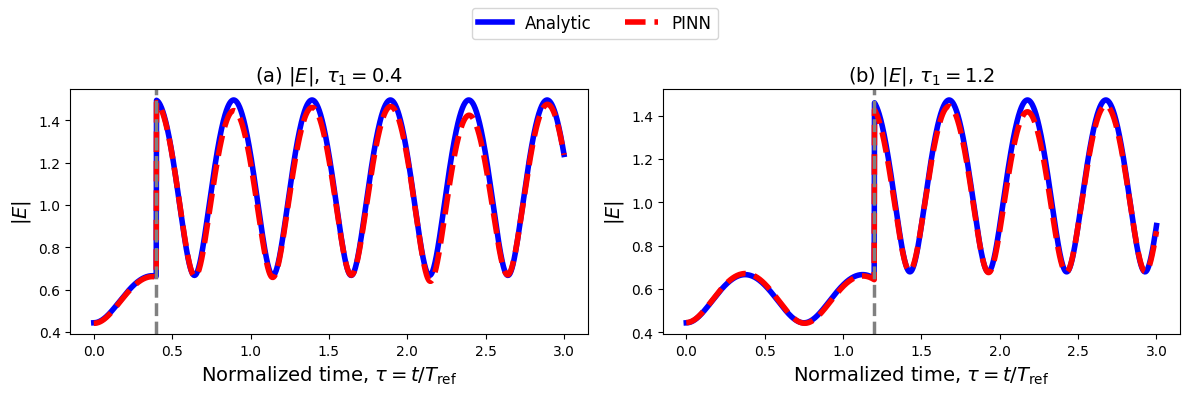

In [ ]:
fig, axes = plt.subplots(1, len(TAU1_LIST), figsize=(6 * len(TAU1_LIST), 4), squeeze=False)

labels = ["(a)", "(b)"]

for ax, tau1, label in zip(axes[0], TAU1_LIST, labels):
    tau, u_true, u_pred = results[tau1]["solution"]

    ax.plot(tau, np.abs(u_true), lw=4, label="Analytic", color = 'blue')
    ax.plot(tau, np.abs(u_pred), linestyle="--", lw=4, label="PINN", color = 'red')
    ax.axvline(tau1, color="gray", lw=2.5, linestyle="--")

    ax.set_title(fr"{label} $|E|$, $\tau_1={tau1}$", fontsize=14)
    ax.set_xlabel(r"Normalized time, $\tau=t/T_{\rm ref}$", fontsize=14)
    ax.set_ylabel(r"$|E|$", fontsize=14)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    fontsize=12
)

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()
